In [16]:
import fitsio as fio
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from pycorr import (
    TwoPointCorrelationFunction, TwoPointEstimator, NaturalTwoPointEstimator, utils, setup_logging
)

In [17]:
def fetch_desi_files(tgt, randoms=False):
    try:
        root = Path(
            '/global/cfs/projectdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/nonKP'
            )
        path = f'{tgt}{"_[0-9]*_" if randoms else "_"}clustering{".ran" if randoms else ".dat"}.fits'
        files = list(root.glob(path))
        if not files:
            raise FileNotFoundError(f"No files found for path: {path}")
        return files
    except PermissionError:
        raise

In [19]:
ROOT = Path('../crosscorr/run8/')
TARGET = Path('ELGnotqso')

In [20]:
def get_file(b1, b2, moc, tgt):
    """
    Get the file name for given redshift bins and MOC.
    """
    DIR = ROOT / tgt 
    return f'{DIR}/{tgt}__b1x{b1}_b2x{b2}_moc{moc}.npy'

def get_bins(name):
    return np.loadtxt(f'{ROOT}/bins/bins_{name}.txt', dtype=float)

In [21]:
result = TwoPointCorrelationFunction.load(get_file(1, 1, 0, 'ELGnotqso'))

In [22]:
result.corr

array([-1.47426501e-01, -9.10122576e-02, -8.42362883e-02, -1.01069849e-01,
       -8.25919149e-02, -4.30674450e-02, -3.08036732e-02, -2.14325655e-02,
        6.23211656e-03, -6.58558042e-03, -7.42537671e-03, -2.91267100e-02,
       -2.44395133e-02, -1.74581760e-02,  1.20359496e-02,  1.95338955e-02,
        2.60273002e-02,  5.28745441e-04,  7.40175392e-03,  1.21977398e-02,
        1.78624591e-02,  1.28649335e-05,  1.53304014e-02,  9.81687407e-03,
       -3.83537678e-03, -6.91744261e-03, -1.09801368e-02, -1.11805781e-02,
       -1.40884948e-02, -2.62800275e-02])

In [33]:
dir(result)

['D1D2',
 'D1R2',
 'R1D2',
 'R1R2',
 'XX',
 '__add__',
 '__call__',
 '__class__',
 '__copy__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__mul__',
 '__ne__',
 '__new__',
 '__radd__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__rmul__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_tuple_requires',
 'concatenate_x',
 'copy',
 'corr',
 'count_names',
 'deepcopy',
 'edges',
 'from_state',
 'get_corr',
 'load',
 'log_critical',
 'log_debug',
 'log_error',
 'log_info',
 'log_warning',
 'logger',
 'mode',
 'mpicomm',
 'name',
 'ndim',
 'normalize',
 'plot',
 'rebin',
 'requires',
 'run',
 'save',
 'save_txt',
 'select',
 'sep',
 'sepavg',
 'seps',
 'shape',
 'slice',
 'sum',
 'with_mpi',
 'with_shifted',
 'wrap']

In [34]:
result.corr

array([-0.11091908, -0.05720076, -0.05118181, -0.06540242, -0.06198144,
       -0.02897137, -0.01573141, -0.00738732,  0.01502694,  0.00209775,
        0.00172083, -0.02138106, -0.01597725, -0.01120994,  0.017467  ,
        0.02478469,  0.028876  ,  0.00294366,  0.01162791,  0.01436324,
        0.0180478 , -0.0018641 ,  0.0129392 ,  0.00827362, -0.00454349,
       -0.00869575, -0.01153972, -0.00971449, -0.01367272, -0.02559255])

In [ ]:
result.rebin

<bound method BaseTwoPointEstimator.rebin of <pycorr.twopoint_estimator.LandySzalayTwoPointEstimator object at 0x7fc0421e2510>>

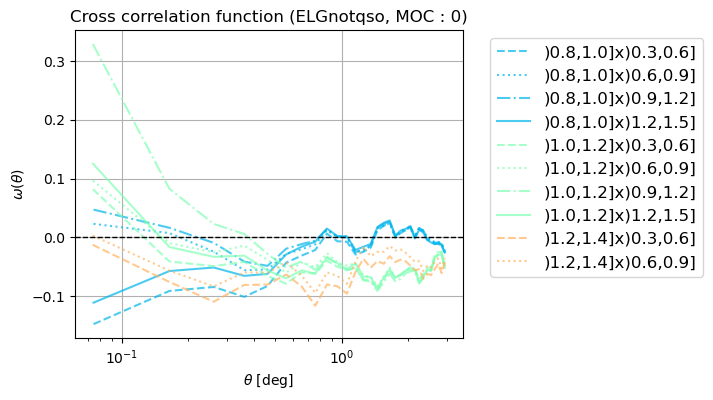

In [56]:
bhsc = get_bins('hsc')
btgt = get_bins('elg')
tgt = 'ELGnotqso'
moc_idx = 0

cmap = plt.get_cmap('rainbow')
plt.figure(figsize=(5, 4))

ax = plt.gca()
for i in range(1, len(btgt)-1):
    for j in range(1, len(bhsc)):
        if i == 3 and j > 2:
            continue
        result = TwoPointCorrelationFunction.load(get_file(i, j, moc_idx, tgt))
        ls = '-' 
        if j == 1:
            ls = '--'
        if j == 2:
            ls = ':'
        if j == 3:
            ls = '-.'
        ax.plot(
            result.sep, 
            result.corr, 
            alpha=0.7,
            linestyle=ls,
            label=f'){btgt[i-1]:.1f},{btgt[i]:.1f}]x){bhsc[j-1]:.1f},{bhsc[j]:.1f}]',
            color=cmap(i/(len(btgt)-1)),
            )

ax.set_xlabel(r'$\theta$ [deg]')
ax.set_ylabel(r'$\omega(\theta)$')
ax.grid(True)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
ax.set_title(f'Cross correlation function ({tgt}, MOC : {moc_idx})', fontsize=12)

#ax.set_yscale('log')
plt.axhline(0, color='k', linestyle='--', lw=1)
plt.xscale('log')

In [ ]:
files = fetch_desi_files('LRG', randoms=True)
fio.FITS(files[0])[1].get_colnames()

In [8]:
files = fetch_desi_files('ELGnotqso', randoms=True)
btgt = get_bins('elg')

z_per_z_bin = []
for f in files[:2]:
    try:
        with fio.FITS(f, 'r') as hdul:
            data = np.array(hdul[1].read(columns='Z'))
            print(data[:10])
            z_per_z_bin.extend(np.digitize(data, btgt, right=True))
            print(f"File: {f.stem}, Number of rows: {len(data)}")
    except Exception as e:
        print(f"Error reading file {f.stem}: {e}")

[0.87462935 0.97988902 1.34145495 0.80153387 1.0307199  0.88014099
 1.35565704 1.12549341 0.8690892  1.04872632]
File: ELGnotqso_4_clustering.ran, Number of rows: 25878470
[1.13777836 0.9251811  1.34804316 0.85013647 0.99332739 1.21299459
 1.32440692 0.87464542 1.03764136 1.36090095]
File: ELGnotqso_14_clustering.ran, Number of rows: 25880985


Text(0.5, 1.0, 'Redshift distribution of first\n2 random files ELGnotqso, subsampled x100')

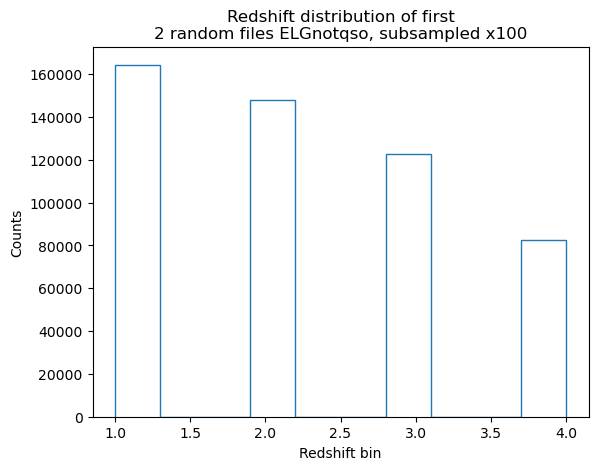

In [11]:
plt.hist(z_per_z_bin[0::100], histtype='step', lw=2)
plt.xlabel('Redshift bin')
plt.ylabel('Counts')
plt.title('Redshift distribution of first\n2 random files ELGnotqso, subsampled x100')

In [16]:
table = fio.FITS(Path(
                    '/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/hsc/cat/hscy3_cat.fits'
                    ))

In [18]:
pz = table[1]['dnnz_photoz_best'].read()

Text(0.5, 1.0, 'Photo-z distribution (HSC)')

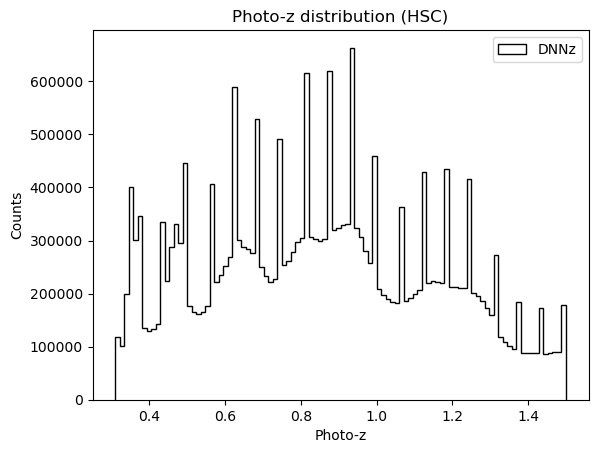

In [19]:
plt.hist(pz, bins=100, histtype='step', color='k', lw=2, label='DNNz')
plt.xlabel('Photo-z')
plt.ylabel('Counts')
plt.legend()
plt.title('Photo-z distribution (HSC)')

In [ ]:
import fitsio as fio
import os

os.listdir('/global/cfs/projectdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/nonKP/')

In [82]:
tbl = fio.FITS(
    '/global/cfs/projectdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/nonKP/ELGnotqso_clustering.dat.fits'
    )

In [83]:
sz = tbl[1]['Z'].read()

In [87]:
min(sz), max(sz)

(0.8000000181478555, 1.5999997110135349)

In [ ]:
len(sz)
bins_bgs = np.arange(0, 0.6, 0.1) # 0 < z < 0.6
bins_lrg = np.arange(0.4, 1.2, 0.1) # 0.4 < z < 1
bhsc = np.arange(0.8, 1.7, 0.1) # 0.6 < z < 1.6 => 0.8 < z < 1.6 in redshift distribution
bins_qso = np.arange(0.8, 3.4, 0.1) # 0.9 < z < 2.1

Text(0.5, 1.0, 'ELGnotqso redshift distribution')

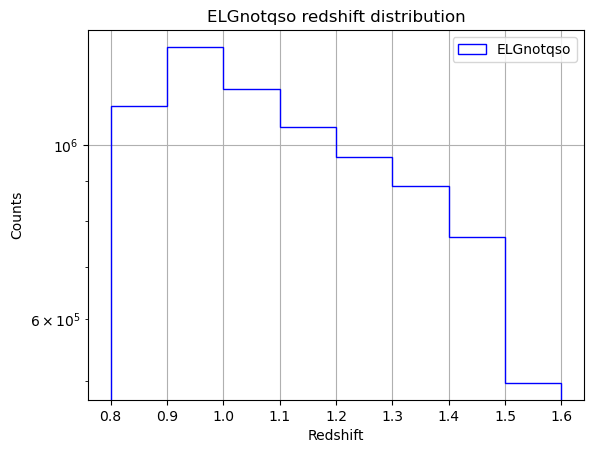

In [ ]:
plt.hist(sz, bins=bhsc, histtype='step', color='blue', lw=2, label='ELGnotqso')
plt.legend()
plt.yscale('log')
plt.ylabel('Counts')
plt.xlabel('Redshift')
plt.grid()
plt.title('ELGnotqso redshift distribution')

In [20]:
cat = fio.FITS(
    '/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/hsc/cat/hscy3_cat.fits'
    )
cat[1].get_colnames()
pz = cat[1]['dnnz_photoz_best'].read()

1.5 0.31


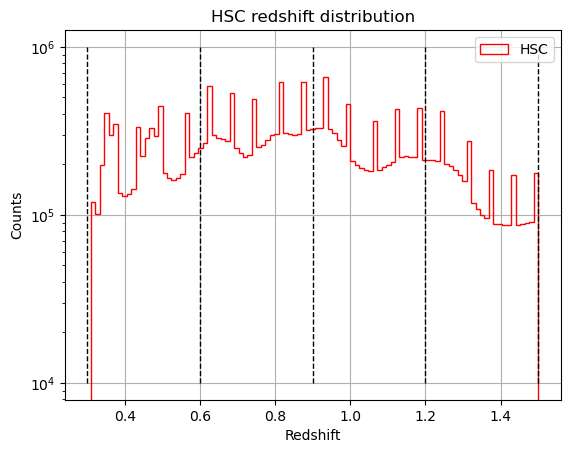

In [26]:
#bins_hsc = np.arange(0.3, 1.8, 0.3)
plt.hist(pz, bins=100, histtype='step', color='red', lw=2, label='HSC')
plt.vlines(
    [0.3, 0.6, 0.9, 1.2, 1.5], 
    ymin=1e4, ymax=1e6,
    color='black', linestyle='--', lw=1
    )
plt.legend()
plt.yscale('log')
plt.ylabel('Counts')
plt.xlabel('Redshift')
plt.grid()
plt.title('HSC redshift distribution')
print(max(pz), min(pz))

In [27]:
np.digitize(pz, bins_hsc)

array([2, 3, 1, ..., 4, 2, 3])

In [11]:
result.edges

[array([0.01      , 0.10966667, 0.20933333, 0.309     , 0.40866667,
        0.50833333, 0.608     , 0.70766667, 0.80733333, 0.907     ,
        1.00666667, 1.10633333, 1.206     , 1.30566667, 1.40533333,
        1.505     , 1.60466667, 1.70433333, 1.804     , 1.90366667,
        2.00333333, 2.103     , 2.20266667, 2.30233333, 2.402     ,
        2.50166667, 2.60133333, 2.701     , 2.80066667, 2.90033333,
        3.        ])]

In [4]:
import numpy as np
np.logspace(np.log10(0.001), np.log10(3), 71)

array([1.00000000e-03, 1.12117437e-03, 1.25703197e-03, 1.40935202e-03,
       1.58012936e-03, 1.77160054e-03, 1.98627312e-03, 2.22695851e-03,
       2.49680880e-03, 2.79935803e-03, 3.13856847e-03, 3.51888253e-03,
       3.94528089e-03, 4.42334782e-03, 4.95934420e-03, 5.56028960e-03,
       6.23405418e-03, 6.98946176e-03, 7.83640538e-03, 8.78597685e-03,
       9.85061205e-03, 1.10442538e-02, 1.23825342e-02, 1.38829800e-02,
       1.55652413e-02, 1.74513496e-02, 1.95660059e-02, 2.19369043e-02,
       2.45950949e-02, 2.75753900e-02, 3.09168204e-02, 3.46631466e-02,
       3.88634315e-02, 4.35726833e-02, 4.88525757e-02, 5.47722558e-02,
       6.14092493e-02, 6.88504763e-02, 7.71933893e-02, 8.65472495e-02,
       9.70345578e-02, 1.08792659e-01, 1.21975541e-01, 1.36755850e-01,
       1.53327154e-01, 1.71906475e-01, 1.92737134e-01, 2.16091934e-01,
       2.42276738e-01, 2.71634469e-01, 3.04549604e-01, 3.41453210e-01,
       3.82828587e-01, 4.29217600e-01, 4.81227771e-01, 5.39540243e-01,
      